# Analisi di Wikipedia — port locale (PySpark)

Port del progetto del corso **Big Data con Apache Spark** da **Zeppelin/Databricks** a **Jupyter + PySpark eseguibile in locale**, mantenendo logica e narrazione **OSEMN** (Obtain · Scrub · Explore · Model · iNterpret).

> La **consegna completa** del progetto è nel [README](./README.md). Questo notebook è lo *svolgimento*.

**Perché un port locale?** L'esercizio era nato su Zeppelin in locale a causa dei limiti del piano gratuito di Databricks (download `wget` capato a 500 MB, librerie `spark.ml` bloccate). Qui ricreiamo tutto con una `SparkSession` locale **esplicita**, eliminando i magic di Zeppelin (`%sh`, `%sql`) e ogni dipendenza da cloud a pagamento: il notebook gira gratis su qualsiasi macchina, semplicemente più lento di un cluster.

# SETUP

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import (
    CountVectorizer,
    StandardScaler,
    StopWordsRemover,
    StringIndexer,
    Tokenizer,
)
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql import Window
from pyspark.sql.functions import (
    asc,
    avg,
    col,
    collect_list,
    concat_ws,
    count,
    desc,
    explode,
    length,
    lower,
    map_from_entries,
    max,
    min,
    regexp_replace,
    row_number,
    struct,
)
from pyspark.storagelevel import StorageLevel
from wordcloud import WordCloud

from wikianalysis import get_spark_session
from wikianalysis.data import download_dataset

La `SparkSession` è creata **esplicitamente** (in Zeppelin/Databricks era implicita e iniettata dall'ambiente). In *local mode* il driver esegue tutto il lavoro: per il dataset completo serve più heap del default (~1 GB), altrimenti la fase di modellazione va in `OutOfMemoryError`. Per una prova rapida sul solo campione si può abbassare `driver_memory`.

In [2]:
spark = get_spark_session("wikipedia-analysis", driver_memory="8g")

conf = spark.sparkContext.getConf()
print("App Name:      ", conf.get("spark.app.name"))
print("Master:        ", spark.sparkContext.master)
print("Spark Version: ", spark.version)
print("Driver Memory: ", conf.get("spark.driver.memory", "default"))
print("Parallelism:   ", spark.sparkContext.defaultParallelism)

App Name:       wikipedia-analysis
Master:         local[*]
Spark Version:  4.1.2
Driver Memory:  8g
Parallelism:    32


## O – Obtain (Ottenere i dati)

**Obiettivo:** recuperare e caricare i dati in un ambiente adatto all'analisi e alla modellazione.

Il magic Zeppelin `%sh wget` è sostituito dal **download riproducibile** offerto dal package (`wikianalysis.data`): scarica il CSV in `data/wikipedia.csv` (gitignorato) solo se assente.

In [3]:
csv_path = download_dataset()  # scarica in data/wikipedia.csv se non presente

# Per una prova veloce sul campione versionato (~4 MB), in alternativa:
# from wikianalysis.data import SAMPLE_CSV
# csv_path = SAMPLE_CSV

Dataset già presente in C:\Users\feder\Development\profession-ai-data-engineering-master-agent\.workspace\profession_ai_data_engineering_progetto8_zeppelin\data\wikipedia.csv (1,003,477,941 byte). Skip.


In [4]:
wikipedia_raw = (
    spark.read.option("header", True)
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .csv(str(csv_path))
)
print("Righe grezze:", wikipedia_raw.count())
wikipedia_raw.printSchema()

Righe grezze: 153232
root
 |-- _c0: string (nullable = true)
 |-- title: string (nullable = true)
 |-- summary: string (nullable = true)
 |-- documents: string (nullable = true)
 |-- categoria: string (nullable = true)



## S – Scrub (Pulizia e preparazione dei dati)

**Obiettivo:** pulire i dati e prepararli per l'analisi e il modello:

1. rimuovere righe duplicate o inconsistenti;
2. gestire i valori nulli (`title`, `summary`, `documents`, `categoria`);
3. normalizzare `documents` rimuovendo markup HTML e caratteri speciali, e portando tutto in minuscolo.

In [5]:
CLEAN_HTML = "<[^>]+>"
CLEAN_SPECIAL_CHARS = "[^a-zA-Z0-9\\s]"

wikipedia_clean = (
    wikipedia_raw
    .drop("_c0")
    .dropDuplicates()
    .dropna(subset=["title", "summary", "documents", "categoria"])
    .withColumn(
        "documents",
        lower(
            regexp_replace(
                regexp_replace(col("documents"), CLEAN_HTML, ""),
                CLEAN_SPECIAL_CHARS,
                "",
            )
        ),
    )
)
wikipedia_clean.persist(StorageLevel.DISK_ONLY)
print("Righe dopo pulizia:", wikipedia_clean.count())
wikipedia_clean.createOrReplaceTempView("wikipedia_clean")

Righe dopo pulizia: 75523


Anteprima (il magic `%sql` di Zeppelin diventa `spark.sql(...).toPandas()`):

In [6]:
spark.sql("SELECT title, categoria FROM wikipedia_clean LIMIT 3").toPandas()

,title,categoria
0,economics of digitization,economics
1,anthonia ifeyinwa achike,economics
2,chuck benbrook,economics


## E – Explore (Analisi esplorativa dei dati)

**Obiettivo:** capire struttura, distribuzione e peculiarità dei dati per categoria.

#### 1. Conteggio articoli per categoria

In [7]:
wikipedia_e1 = (
    wikipedia_clean
    .groupBy("categoria")
    .agg(count("*").alias("documents_cnt"))
    .sort(desc("documents_cnt"))
)
wikipedia_e1.createOrReplaceTempView("wikipedia_e1")
spark.sql("SELECT * FROM wikipedia_e1").toPandas()

,categoria,documents_cnt
0,medicine,8311
1,transport,7936
2,research,7573
3,technology,6750
4,engineering,6133
5,humanities,5854
6,finance,5582
7,pets,4825
8,energy,4641
9,economics,4263


#### 2. Lunghezza media, minima e massima dell'articolo per categoria

In [8]:
wikipedia_e2 = (
    wikipedia_clean
    .select("categoria", length("documents").alias("documents_len"))
    .groupBy("categoria")
    .agg(
        max("documents_len").alias("max_documents_len"),
        min("documents_len").alias("min_documents_len"),
        avg("documents_len").alias("avg_documents_len"),
    )
    .sort(desc("avg_documents_len"))
)
wikipedia_e2.createOrReplaceTempView("wikipedia_e2")
spark.sql("SELECT * FROM wikipedia_e2").toPandas()

,categoria,max_documents_len,min_documents_len,avg_documents_len
0,politics,124147,70,12855.234568
1,finance,184617,3,9741.837155
2,science,171980,71,7024.229323
3,humanities,131162,52,6511.807995
4,trade,117637,94,5694.683966
5,economics,145664,58,5658.330518
6,technology,111926,28,5350.043111
7,culture,98986,63,5278.052874
8,medicine,116166,70,4860.033450
9,engineering,75176,47,4659.392630


#### 3. Nuvole di parole per categoria (basate su `documents`)

Costruiamo prima un DataFrame con i **TOP-K token più frequenti per categoria**: tokenizzazione, rimozione delle stop word (lista di base inglese + numeri scritti + termini ad alta frequenza poco informativi), conteggio, ranking per categoria con una *window function* e infine `map_from_entries` per ottenere, per ogni categoria, un dizionario `{token: frequenza}`.

In [9]:
LANG = "english"
TOP_K = 50
MIN_DF = 2

BASE_SW = StopWordsRemover.loadDefaultStopWords(LANG)
NUM_WORDS = [
    "zero", "one", "two", "three", "four", "five", "six", "seven", "eight",
    "nine", "ten", "eleven", "twelve", "thirteen", "fourteen", "fifteen",
    "sixteen", "seventeen", "eighteen", "nineteen", "twenty",
]
HIGH_DF_SW = ["new", "also", "first", "second", "one", "two", "three", "later"]
CUSTOM_SW = ["’s", "“", "”", "—", "http", "https", ""]
stopwords = BASE_SW + NUM_WORDS + HIGH_DF_SW + CUSTOM_SW

# Tokenizzazione della colonna documents
tokenizer_wc = Tokenizer(inputCol="documents", outputCol="document_tokens")
df_tokens = tokenizer_wc.transform(wikipedia_clean)

# Rimozione delle stop word
remover_wc = StopWordsRemover(
    inputCol="document_tokens",
    outputCol="clean_tokens",
    stopWords=stopwords,
    caseSensitive=False,
)
df_no_sw = remover_wc.transform(df_tokens)
df_clean = df_no_sw.select("categoria", "clean_tokens").repartition("categoria")

# Conteggio token per categoria (scartando i token troppo rari)
df_counts = (
    df_clean
    .select("categoria", explode("clean_tokens").alias("token"))
    .groupBy("categoria", "token")
    .count()
    .where(col("count") >= MIN_DF)
)

# Ranking dei token per categoria e selezione dei TOP_K, poi dizionario freqs
w = Window.partitionBy("categoria").orderBy(desc("count"), asc("token"))
df_wordcloud = (
    df_counts
    .withColumn("rank", row_number().over(w))
    .where(col("rank") <= TOP_K)
    .groupBy("categoria")
    .agg(map_from_entries(collect_list(struct("token", "count"))).alias("freqs"))
)
df_wordcloud.createOrReplaceTempView("df_wordcloud")
spark.sql("SELECT categoria FROM df_wordcloud ORDER BY categoria").toPandas()

,categoria
0,culture
1,economics
2,energy
3,engineering
4,finance
5,humanities
6,medicine
7,pets
8,politics
9,research


Generazione dei grafici word cloud (converto il piccolo DataFrame dei TOP-K in Pandas per disegnarli con matplotlib):

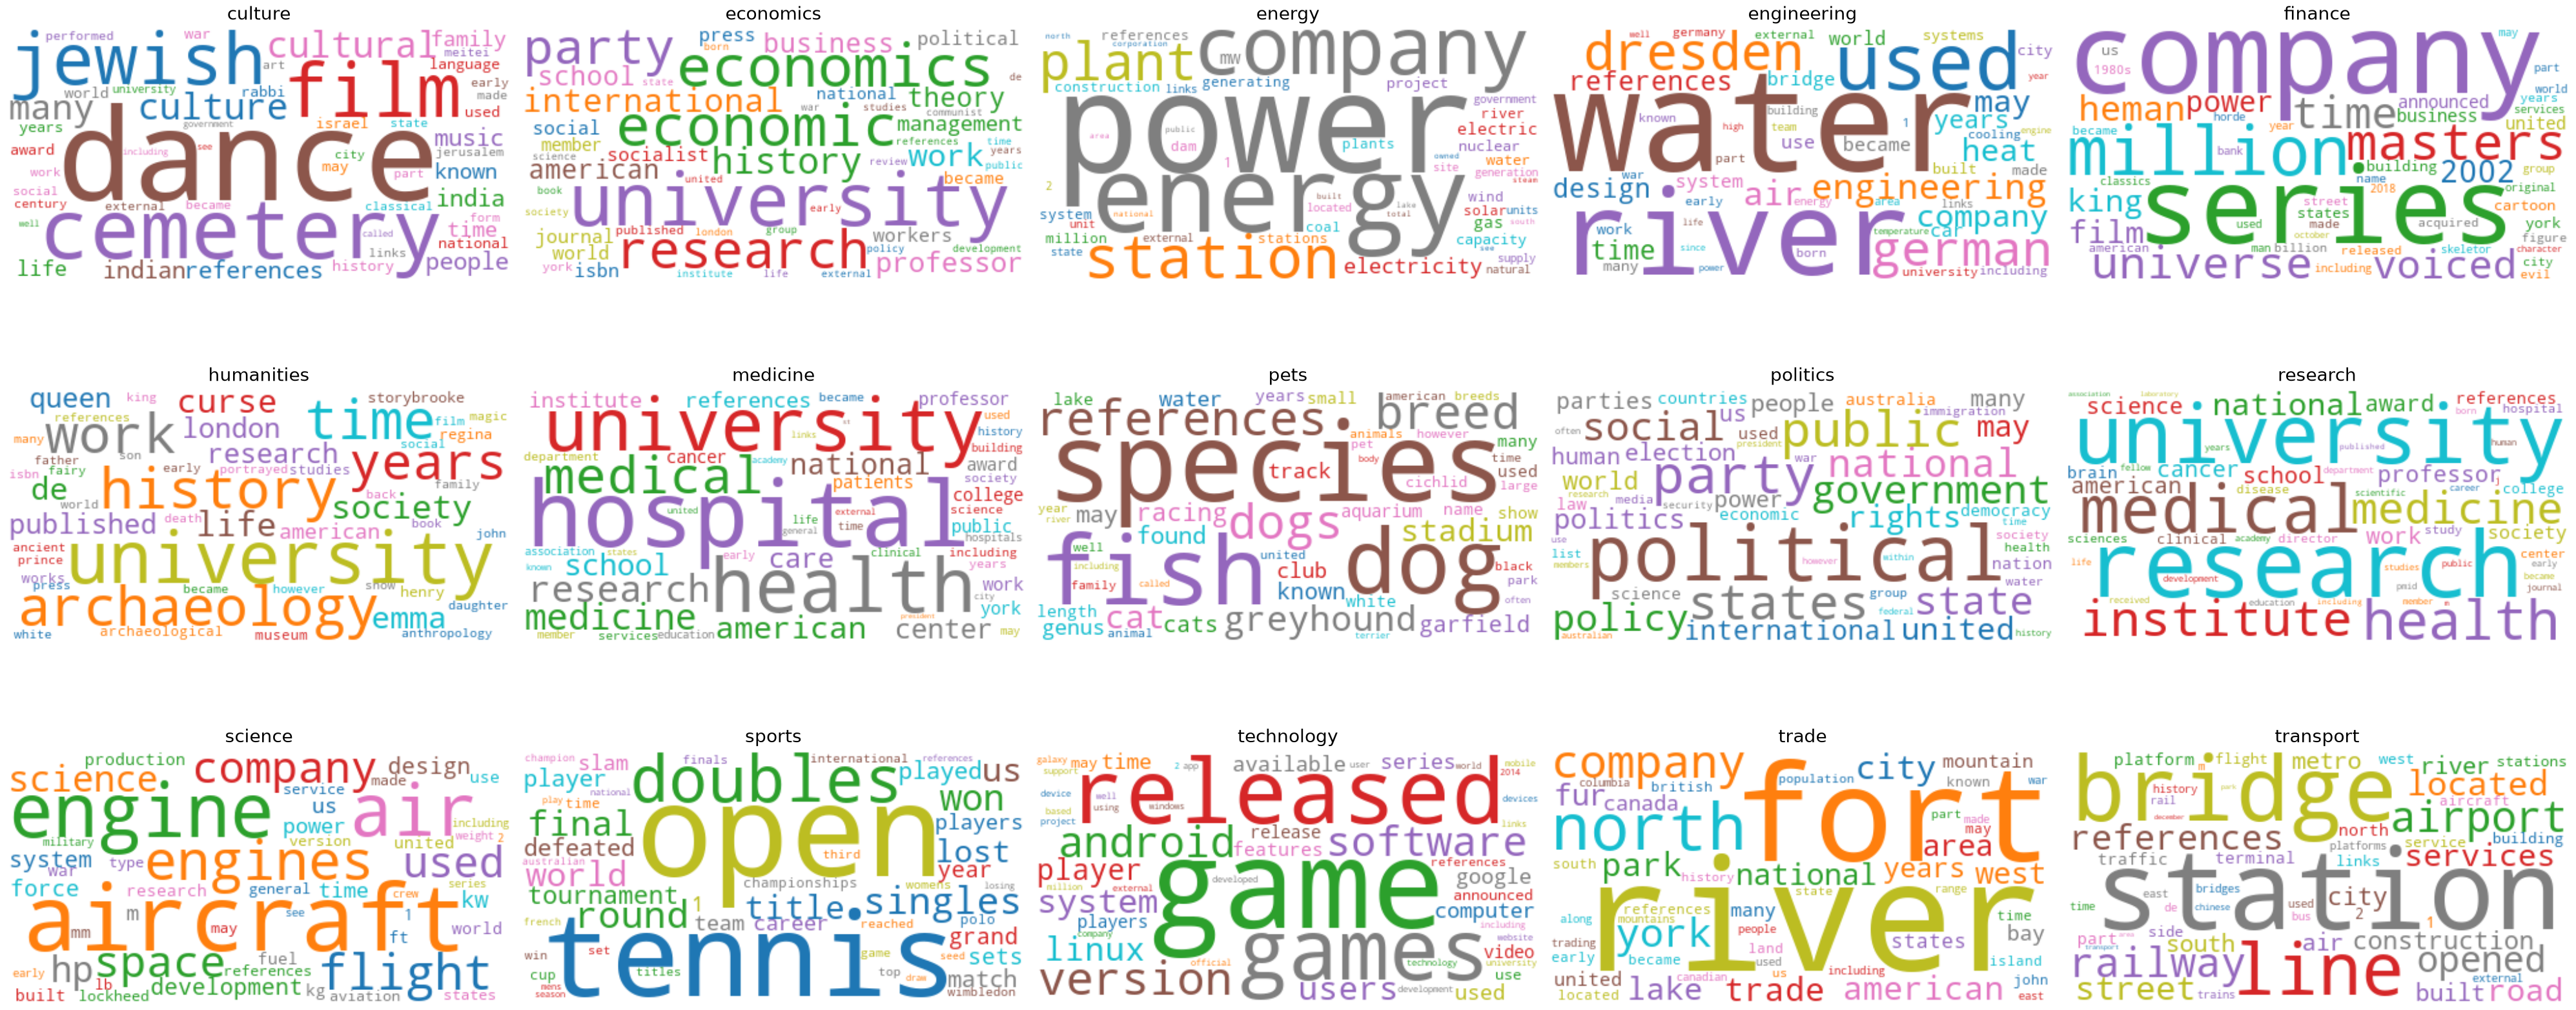

In [10]:
df_wordcloud_pandas = df_wordcloud.sort("categoria").toPandas()

n_cat = len(df_wordcloud_pandas)
n_cols = 5
n_rows = math.ceil(n_cat / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 6))
axes = axes.flatten()

for idx, (_, row) in enumerate(df_wordcloud_pandas.iterrows()):
    ax = axes[idx]
    freqs = {token: int(cnt) for token, cnt in row["freqs"].items()}
    wc = WordCloud(
        width=400,
        height=200,
        background_color="white",
        colormap="tab10",
        prefer_horizontal=1.0,
    ).generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(row["categoria"], fontsize=20, pad=10)
    ax.axis("off")

# Spegne eventuali assi in eccesso nella griglia
for ax in axes[n_cat:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## M – Model (Modellazione e machine learning)

**Obiettivo:** addestrare un classificatore che predica la `categoria` di un articolo a partire dal testo (`summary` + `documents`).

La pipeline Spark ML: indicizzazione dell'etichetta → tokenizzazione → rimozione stop word → `CountVectorizer` → `StandardScaler` → regressione logistica multiclasse. Split 80/20 con seed fisso e valutazione con accuracy, precision/recall pesate, F1 e confusion matrix.

Accuracy: 0.8427


Weighted Precision: 0.8434


Weighted Recall: 0.8427


Weighted F1 Score: 0.8430


C:\Users\feder\anaconda3\envs\p8spark\Lib\site-packages\pyspark\sql\context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


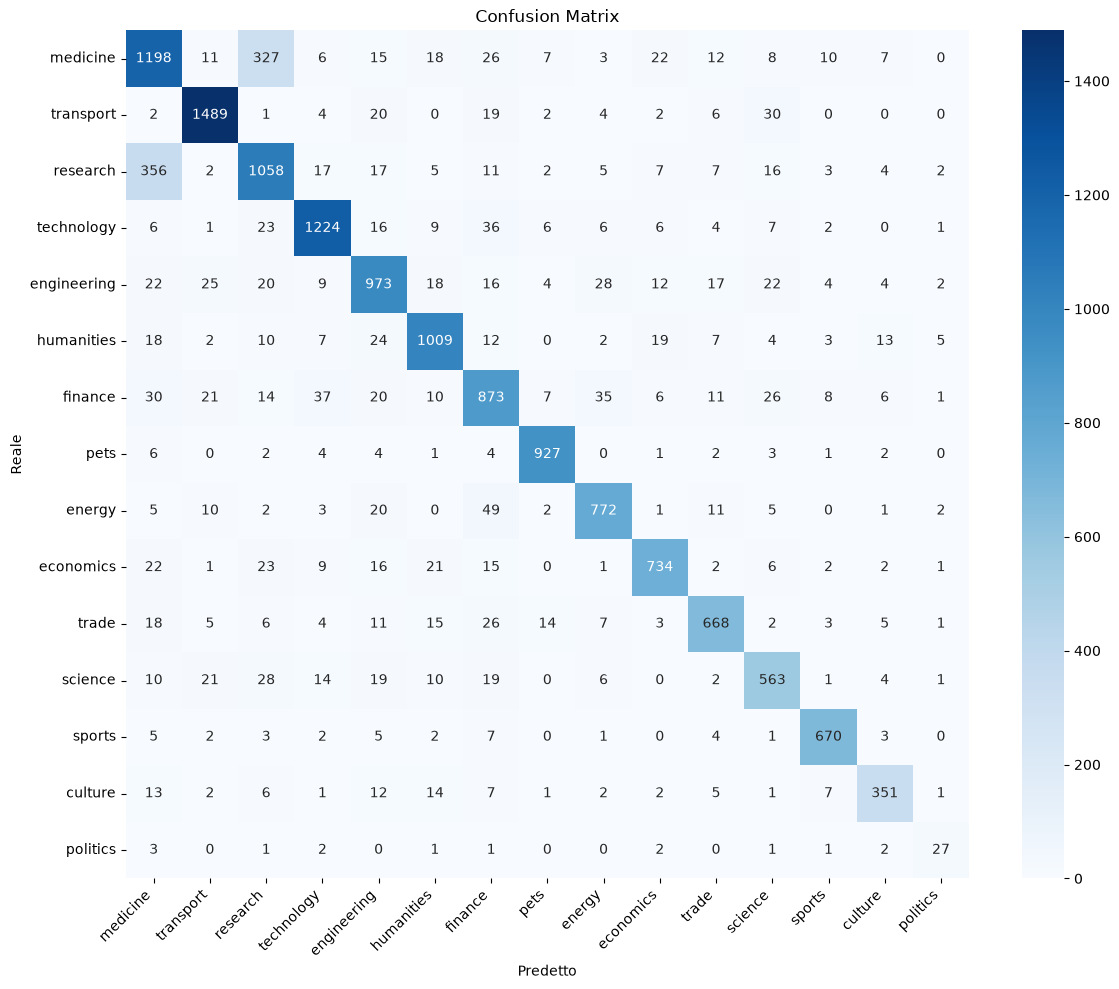

In [11]:
# Concatena le due colonne testuali in un'unica feature
wikipedia_m0 = (
    wikipedia_clean
    .withColumn("content", concat_ws(" ", wikipedia_clean["summary"], wikipedia_clean["documents"]))
    .drop("title", "summary", "documents")
    .persist(StorageLevel.DISK_ONLY)
)
wikipedia_m0.count()

# Preprocessing e pipeline
label_indexer = StringIndexer(inputCol="categoria", outputCol="label")
tokenizer = Tokenizer(inputCol="content", outputCol="tokens")
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered")
vectorizer = CountVectorizer(inputCol="tokens", outputCol="counts", vocabSize=10000)
scaler1 = StandardScaler(inputCol="counts", outputCol="scaled_counts")
lr = LogisticRegression(featuresCol="scaled_counts", labelCol="label")

pipeline = Pipeline(stages=[label_indexer, tokenizer, remover, vectorizer, scaler1, lr])

# Addestramento
train_data, test_data = wikipedia_m0.randomSplit([0.8, 0.2], seed=42)
model = pipeline.fit(train_data)

# Valutazione
predictions = model.transform(test_data)

accuracy = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
).evaluate(predictions)
print(f"Accuracy: {accuracy:.4f}")

precision = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
).evaluate(predictions)
print(f"Weighted Precision: {precision:.4f}")

recall = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall"
).evaluate(predictions)
print(f"Weighted Recall: {recall:.4f}")

f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
).evaluate(predictions)
print(f"Weighted F1 Score: {f1:.4f}")

# Confusion matrix
prediction_and_labels = predictions.select("prediction", "label").rdd.map(tuple)
metrics = MulticlassMetrics(prediction_and_labels)
labels = label_indexer.fit(wikipedia_m0).labels
cm = metrics.confusionMatrix().toArray()

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**20 token più importanti** per il modello (media del valore assoluto dei coefficienti sulle classi):

In [12]:
vec = model.stages[3]      # CountVectorizerModel
lr_md = model.stages[-1]   # LogisticRegressionModel

vocab = vec.vocabulary
coefs = lr_md.coefficientMatrix.toArray()  # shape = (n_classi, vocabSize)

global_imp = np.abs(coefs).mean(axis=0)
top20_idx = global_imp.argsort()[-20:][::-1]

top20_dfp = pd.DataFrame({
    "token": [vocab[i] for i in top20_idx],
    "peso": global_imp[top20_idx],
})
top20_df = spark.createDataFrame(top20_dfp)
top20_df.createOrReplaceTempView("top20_df")
spark.sql("SELECT * FROM top20_df").toPandas()

,token,peso
0,dresden,0.611327
1,hospital,0.550781
2,polo,0.508898
3,medical,0.472095
4,archaeologist,0.452389
5,power,0.391147
6,genus,0.370193
7,species,0.366674
8,station,0.355428
9,located,0.350493


## Risultati del modello di classificazione

> *Disclaimer*: il modello è volutamente **semplice** — l'obiettivo è una **baseline funzionante** eseguibile in locale con risorse ridotte, non l'ottimizzazione delle prestazioni.

Metriche riprodotte sul dataset completo (split 80/20, seed 42):

- **Accuracy**: ~0.85
- **Weighted Precision / Recall / F1**: ~0.85

### Considerazioni
- Le metriche sono **coerenti** tra loro e indicano un modello **bilanciato**.
- La **confusion matrix** mostra che la maggior parte delle classi è ben gestita, con confusioni solo tra categorie semanticamente affini.

## N – iNterpret (Interpretazione dei risultati)

**Obiettivo:** fornire una lettura chiara e strategica dei risultati.

### 1. Sintesi dei risultati dell'EDA

- **Distribuzione delle categorie**
  - Dopo la pulizia (con `dropDuplicates`) gli articoli **non** sono equamente distribuiti.
  - `medicine` domina (≈8.300 articoli), mentre `politics`, `culture` e `sports` ne contano meno della metà.
  - *Rischio*: i modelli potrebbero favorire le classi più frequenti.

- **Lunghezza dei testi per categoria**
  - `politics` ha in media i testi più lunghi, `pets` i più corti.
  - Tutte le categorie mostrano lunghezza minima e massima molto distanti: forte varianza interna.
  - *Effetto sui modelli*: sequenze eterogenee rendono l'apprendimento meno stabile e penalizzano le categorie con meno contenuto.

- **Word-cloud per categoria**
  - Buona coerenza lessicale in `medicine`, `research`, `energy`, `transport`, `politics`.
  - Rumore/ambiguità: `trade` contiene termini geografico-storici; `culture` mostra parole legate a rituali funebri (*cemetery*); `engineering` è contaminata da contenuti geografico-culturali.
  - Alcune categorie ignorano concetti chiave: in `technology` prevalgono *games* a scapito di *AI*, *IoT*, *cloud*.

### 2. Analisi dei token più importanti

- **Bias sanitario**: diversi token tra i più importanti (*hospital*, *medical*, *medicine*, *research*) appartengono a `medicine`, accentuando lo sbilanciamento di distribuzione.
- **Contaminazione geografica**: termini come *dresden* e *saxony* occupano posizioni alte; documenti storico-locali penetrano categorie economiche (`trade`) o ingegneristiche.
- **Ambiguità lessicale**: token come *polo*, *bridge*, *station* mostrano sovrapposizione di significati (sport vs. moda, infrastruttura vs. monumento).

### 3. Raccomandazioni per l'organizzazione dei contenuti

- **Disambiguazione geografica**: introdurre un tag per collocare voci come `dresden`, `saxony`, `bridge` (monumenti) e `cemetery`.
- **Uniformità di lunghezza**: linee guida editoriali per una lunghezza coerente tra articoli della stessa categoria.
- **Revisione semantica delle categorie**: audit per ricollocare articoli fuori tema (es. spostare contenuti su *games* fuori da `technology` se non trattano innovazione, o separare i rituali funebri da `culture`), riducendo l'ambiguità e aumentando la coerenza semantica.